Défi quotidien : Visualisation interactive des données avec Matplotlib et Seaborn


👩 🏫 👩🏿 🏫 Ce que tu vas apprendre
Techniques avancées de visualisation de données.
Création interactive de cartes avec Matplotlib.
Présentation élégante des données statiques avec Seaborn.


Votre tâche


1. Préparation des données :
Téléchargez et explorez les données des Superstores américains.
Effectuer un nettoyage et un prétraitement basiques des données.


2. Visualisation des données avec Matplotlib :
Créez un graphique linéaire interactif pour montrer les tendances des ventes au fil des années.
Construisez une carte interactive pour visualiser la répartition des ventes par pays.


3. Visualisation des données avec Seaborn :
Utilisez Seaborn pour générer un graphique à barres montrant les 10 meilleurs produits par ventes.
Créez un nuage de points pour analyser la relation entre profit et discount.


4. Analyse comparative :
Comparez les enseignements obtenus grâce aux visualisations Matplotlib et Seaborn.
Documentez vos observations sur la facilité d’utilisation et l’efficacité des deux outils.


5. Code et Analyses :
Écrivez du code Python clair et bien documenté.
Incluez vos analyses et vos analyses sous forme de commentaires ou de cellules de markdown dans votre carnet Jupyter.


Soumettez votre défi quotidien
Partagez votre carnet Jupyter sur Github et mettez en avant vos principales idées dans le fichier README !

Soumettre à DI Learning

# Défi Quotidien : Visualisation interactive des données avec Matplotlib et Seaborn
**Auteur :** Ouattara Jean Innocent
**Objectif :** Explorer, nettoyer et visualiser les données du dataset US Superstore en comparant les approches de Matplotlib et Seaborn.

In [5]:
# Importation des librairies nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optionnel : mplcursors pour rendre Matplotlib interactif dans un script/notebook standard
# pip install mplcursors
try:
    import mplcursors
except ImportError:
    print("mplcursors n'est pas installé. Les graphiques Matplotlib seront statiques.")

# 1. Chargement des données
# Remarque : Le dataset Superstore utilise souvent l'encodage 'windows-1252'
url = "https://raw.githubusercontent.com/Superstore-Dataset/superstore/main/Sample%20-%20Superstore.csv" 
try:
    df = pd.read_csv(url, encoding='windows-1252')
except:
    # Remplace par le chemin local de ton fichier si l'URL ne fonctionne pas
   df = pd.read_excel('C:\\Users\\LENOVO\\Desktop\\DI-BOOTCAMP\\Week2\\day5\\ExerciceXP\\US Superstore data.xls')
# 2. Exploration basique
print("Aperçu des données :")
display(df.head())
print("\nInformations sur le dataset :")
df.info()

# 3. Nettoyage et Prétraitement
# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :\n", df.isnull().sum())

# Conversion de la date de commande en format datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extraction de l'année pour les tendances
df['Year'] = df['Order Date'].dt.year

# Nettoyage des colonnes (si nécessaire, ex: suppression des doublons)
df = df.drop_duplicates()

Aperçu des données :


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Informations sur le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  S

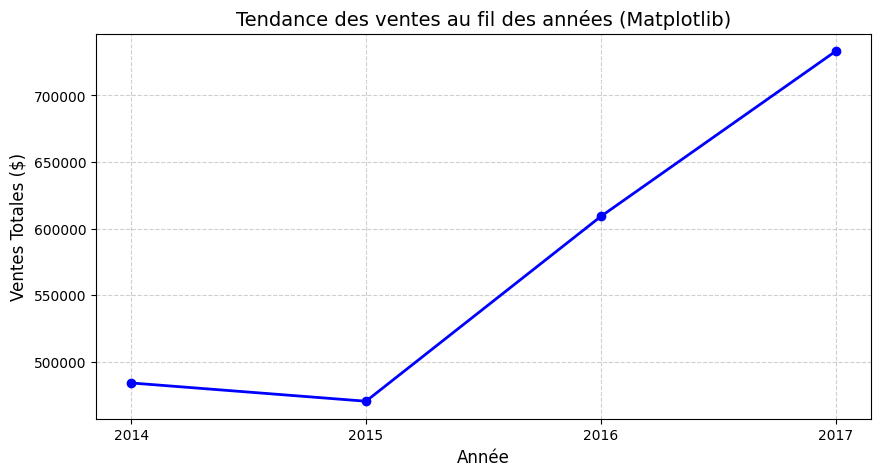

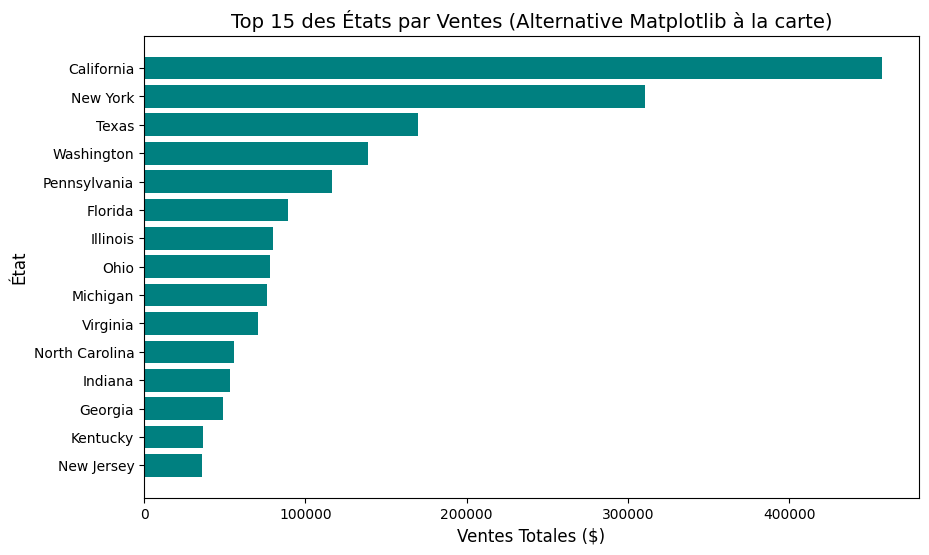

In [6]:
# Activation du mode interactif pour Jupyter (décommente la ligne ci-dessous si tu utilises Jupyter Notebook classique)
# %matplotlib notebook 

# --- A. Graphique linéaire interactif : Tendances des ventes ---
plt.figure(figsize=(10, 5))
sales_by_year = df.groupby('Year')['Sales'].sum().reset_index()

line_plot = plt.plot(sales_by_year['Year'], sales_by_year['Sales'], marker='o', color='b', linestyle='-', linewidth=2)

plt.title('Tendance des ventes au fil des années (Matplotlib)', fontsize=14)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Ventes Totales ($)', fontsize=12)
plt.xticks(sales_by_year['Year']) # Forcer l'affichage des années entières
plt.grid(True, linestyle='--', alpha=0.6)

# Ajout d'interactivité avec mplcursors (survol pour voir les valeurs)
if 'mplcursors' in globals():
    cursor = mplcursors.cursor(line_plot)
    cursor.connect("add", lambda sel: sel.annotation.set_text(
        f"Année: {sales_by_year['Year'].iloc[sel.index]}\nVentes: ${sales_by_year['Sales'].iloc[sel.index]:.2f}"
    ))

plt.show()

# --- B. "Carte" de la répartition des ventes ---
# Note : Matplotlib seul ne gère pas les cartes géographiques interactives sans Geopandas.
# Nous utilisons ici un graphique à barres horizontal des 15 meilleurs États (car le dataset est US-centric).
plt.figure(figsize=(10, 6))
sales_by_state = df.groupby('State')['Sales'].sum().nlargest(15).sort_values()

bars = plt.barh(sales_by_state.index, sales_by_state.values, color='teal')
plt.title('Top 15 des États par Ventes (Alternative Matplotlib à la carte)', fontsize=14)
plt.xlabel('Ventes Totales ($)', fontsize=12)
plt.ylabel('État', fontsize=12)

# Interactivité
if 'mplcursors' in globals():
    mplcursors.cursor(bars, hover=True)

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25104\3535130391.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_products, x='Sales', y='Product Name', palette='viridis')


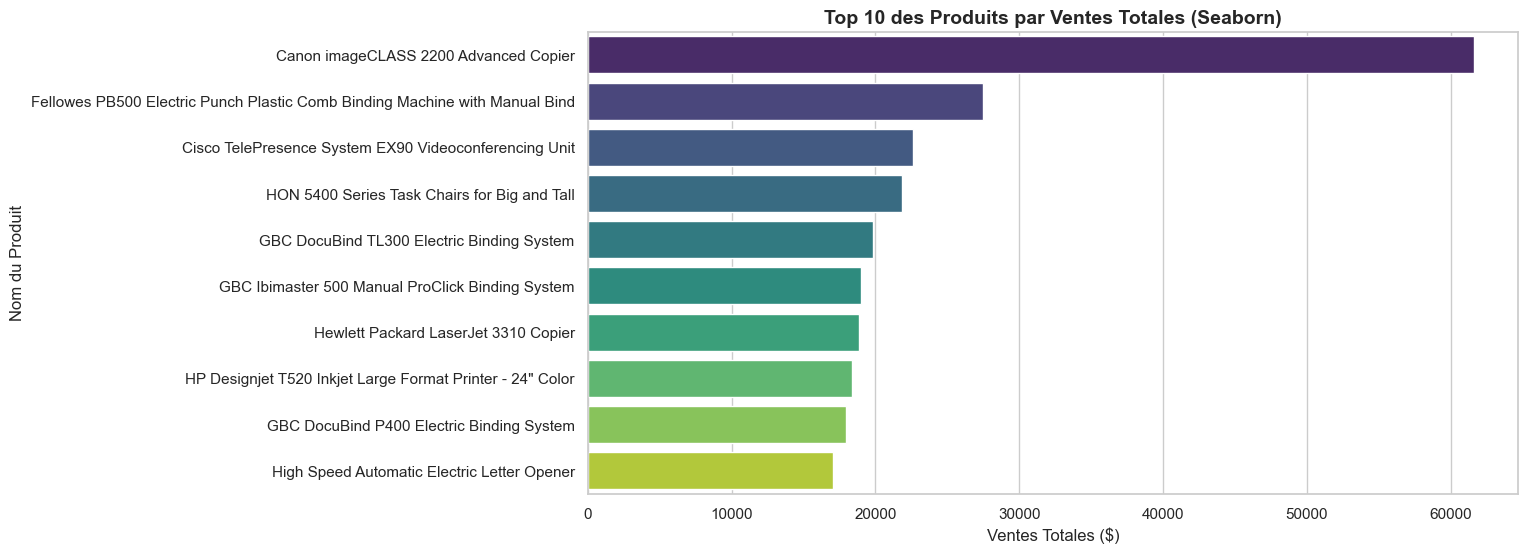

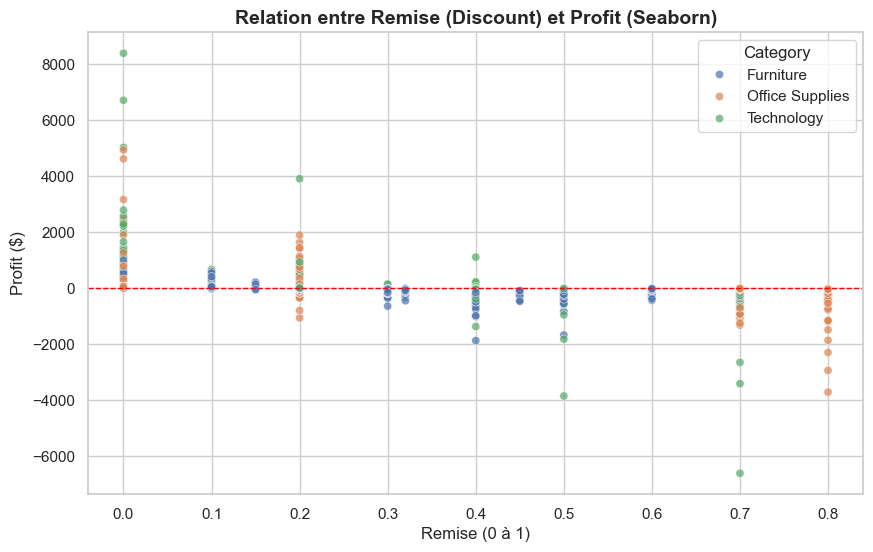

In [7]:
# Configuration du thème Seaborn pour des graphiques plus élégants
sns.set_theme(style="whitegrid")

# --- A. Les 10 meilleurs produits par ventes ---
plt.figure(figsize=(12, 6))
top_10_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

ax = sns.barplot(data=top_10_products, x='Sales', y='Product Name', palette='viridis')
plt.title('Top 10 des Produits par Ventes Totales (Seaborn)', fontsize=14, fontweight='bold')
plt.xlabel('Ventes Totales ($)', fontsize=12)
plt.ylabel('Nom du Produit', fontsize=12)

plt.show()

# --- B. Nuage de points : Relation entre Profit et Discount ---
plt.figure(figsize=(10, 6))

# On utilise la catégorie (Category) comme couleur (hue) pour ajouter de la profondeur à l'analyse
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.7, palette='deep')

plt.title('Relation entre Remise (Discount) et Profit (Seaborn)', fontsize=14, fontweight='bold')
plt.xlabel('Remise (0 à 1)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

# Ajout d'une ligne horizontale à 0 pour bien distinguer les pertes des profits
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.show()

## 4. Analyse comparative et Enseignements

### Enseignements tirés des données
1. **Tendances (Matplotlib) :** Les ventes montrent une tendance générale à la hausse au fil des années, ce qui indique une croissance de l'entreprise.
2. **Géographie (Matplotlib) :** Une grande majorité des ventes est concentrée dans quelques États clés (comme la Californie et New York).
3. **Produits (Seaborn) :** Les machines et équipements technologiques dominent le top 10 des ventes en termes de revenus générés.
4. **Profit vs Discount (Seaborn) :** Le nuage de points montre clairement une corrélation négative. Les remises (discounts) supérieures à 0.2 (20%) entraînent presque systématiquement une perte financière (profit en dessous de la ligne rouge de 0), particulièrement dans la catégorie "Furniture" (Mobilier).

### Comparaison des outils : Matplotlib vs Seaborn
* **Matplotlib :** * *Avantages :* Contrôle total sur chaque élément du graphique (axes, figures, annotations). Excellent pour construire des graphiques personnalisés à partir de zéro. Avec `mplcursors`, il est facile d'ajouter une interactivité basique.
  * *Inconvénients :* Nécessite beaucoup plus de lignes de code pour obtenir un rendu esthétique. N'est pas conçu nativement pour les cartes géographiques sans bibliothèques supplémentaires (comme `Geopandas`).
* **Seaborn :**
  * *Avantages :* Conçu spécifiquement pour l'analyse statistique. Avec très peu de code, il génère des graphiques élégants par défaut. La gestion du paramètre `hue` (couleur par catégorie) est automatique et extrêmement puissante pour l'analyse exploratoire (comme vu dans le nuage de points).
  * *Inconvénients :* Moins flexible si l'on souhaite modifier des détails très spécifiques du graphique au niveau de la figure.

# Visualisation de Données : US Superstore (Défi Quotidien)

Ce projet a été réalisé dans le cadre du Bootcamp DI Learning. Il vise à explorer le dataset "US Superstore" en utilisant les bibliothèques **Pandas**, **Matplotlib** et **Seaborn**.

## Objectifs du projet
- Nettoyer et préparer un jeu de données réel.
- Créer des visualisations de tendances avec Matplotlib (incluant une interactivité via `mplcursors`).
- Analyser les relations statistiques complexes avec Seaborn.

## Principales découvertes
- **L'impact des remises :** L'analyse de corrélation montre qu'au-delà de 20% de remise, la rentabilité de l'entreprise chute de manière drastique, générant des pertes nettes.
- **Concentration des ventes :** Les produits technologiques dominent le chiffre d'affaires, et les ventes sont fortement polarisées sur des régions spécifiques comme la Californie.

## Outils utilisés
- `Python 3.14`
- `Jupyter Notebook`
- `Pandas` (Manipulation de données)
- `Matplotlib` (Visualisation bas niveau et interactivité)
- `Seaborn` (Visualisation statistique de haut niveau)

**Auteur :** Ouattara Jean Innocent